# İlk embedding’iniz

## Egzersiz hedefleri:

- NLP için ilk RNN'nizi çalıştırın
- Gömme kavramının ne olduğunu ilk kez deneyimleyin

<hr>

Kelimeler, sinir ağına kolayca besleyebileceğiniz şeyler değildir. Bu nedenle, onları daha anlamlı bir şeye dönüştürmemiz gerekir. 

Ve _Embeddings_ kavramı tam da bunun için vardır! Herhangi bir kelimeyi vektörel bir temsil üzerine eşler (bu, her kelimeyi bir vektörle temsil etmenin süslü bir yoludur ;) ). Örneğin, `köpek` kelimesi gömme uzayında $(w_1, w_2, ..., w_n)$ vektörü ile temsil edilebilir ve biz de $(w_k)_k$ ağırlıklarını öğreniriz.

Öyleyse haydi başlayalım.

# Data

❓ **Soru** ❓ Öncelikle verileri yükleyelim. Fonksiyonda neler olduğunu anlamanıza gerek yok, burada önemi yok.

⚠️ **Uyarı** ⚠️ `load_data` fonksiyonunun bir `percentage_of_sentences` argümanı vardır. Bilgisayarınıza bağlı olarak, çok fazla cümle bilgisayarınızı yavaşlatabilir veya hatta dondurabilir - RAM'iniz taşabilir. Bu nedenle, **cümlelerin %10'uyla başlamalı** ve bilgisayarınızın bunu kaldırabildiğini görmelisiniz. Aksi takdirde, daha düşük bir sayı ile yeniden çalıştırın. 

⚠️ **DISCLAIMER** ⚠️ **_En büyüğü kimde_ (RAM) oyununu oynamaya gerek yok!** Buradaki amaç, modellerinizi hızlı bir şekilde çalıştırarak prototip oluşturmaktır. Gerçek hayatta bile, hızlı bir şekilde döngü ve hata ayıklama yapmak için verilerinizin bir alt kümesiyle başlamanız önerilir. Bu nedenle, yalnızca en iyi doğruluğu elde etmek istiyorsanız sayıyı artırın. 

In [1]:
#####################################################
### Verileri yüklemek için bu hücreyi çalıştırın  ###
#####################################################

import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.text import text_to_word_sequence

def load_data(percentage_of_sentences=None):
    train_data, test_data = tfds.load(name="imdb_reviews", split=["train", "test"], batch_size=-1, as_supervised=True)

    train_sentences, y_train = tfds.as_numpy(train_data)
    test_sentences, y_test = tfds.as_numpy(test_data)

    # Tüm verilerin yalnızca belirli bir yüzdesini alın
    if percentage_of_sentences is not None:
        assert(percentage_of_sentences> 0 and percentage_of_sentences<=100)

        len_train = int(percentage_of_sentences/100*len(train_sentences))
        train_sentences, y_train = train_sentences[:len_train], y_train[:len_train]

        len_test = int(percentage_of_sentences/100*len(test_sentences))
        test_sentences, y_test = test_sentences[:len_test], y_test[:len_test]

    X_train = [text_to_word_sequence(_.decode("utf-8")) for _ in train_sentences]
    X_test = [text_to_word_sequence(_.decode("utf-8")) for _ in test_sentences]

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_data(percentage_of_sentences=10)

2026-03-30 14:47:10.379614: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-30 14:47:28.783639: W external/local_tsl/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

Generating test examples...:   0%|          | 0/25000 [00:00<?, ? examples/s]

Shuffling /Users/macos/tensorflow_datasets/imdb_reviews/plain_text/incomplete.V52ZZO_1.0.0/imdb_reviews-test.t…

Generating unsupervised examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /Users/macos/tensorflow_datasets/imdb_reviews/plain_text/incomplete.V52ZZO_1.0.0/imdb_reviews-unsupe…

Dataset imdb_reviews downloaded and prepared to /Users/macos/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


Verileri yüklediğinize göre, şimdi bir göz atalım!

❓ **Soru** ❓ Burada verilerle oynayabilirsiniz. Özellikle, `X_train` ve `X_test` cümle listeleridir. Bunlardan bazılarını, `y_train` ve `y_test` içinde saklanan ilgili etiketleriyle birlikte yazdırın.

In [2]:
# İlk film yorumunu (X_train içindeki 0. indeks) yazdıralım
print("--- İLK YORUM (X_train[0]) ---")
print(X_train[0])

# Bu yorumun etiketini (y_train içindeki 0. indeks) yazdıralım
print("\n--- ETİKETİ (y_train[0]) ---")
print("Etiket:", y_train[0])

# Etiketin anlamını da ekleyelim (0: Negatif, 1: Pozitif)
duygu = "Pozitif" if y_train[0] == 1 else "Negatif"
print(f"Yani bu yorum: {duygu}")

--- İLK YORUM (X_train[0]) ---
['this', 'was', 'an', 'absolutely', 'terrible', 'movie', "don't", 'be', 'lured', 'in', 'by', 'christopher', 'walken', 'or', 'michael', 'ironside', 'both', 'are', 'great', 'actors', 'but', 'this', 'must', 'simply', 'be', 'their', 'worst', 'role', 'in', 'history', 'even', 'their', 'great', 'acting', 'could', 'not', 'redeem', 'this', "movie's", 'ridiculous', 'storyline', 'this', 'movie', 'is', 'an', 'early', 'nineties', 'us', 'propaganda', 'piece', 'the', 'most', 'pathetic', 'scenes', 'were', 'those', 'when', 'the', 'columbian', 'rebels', 'were', 'making', 'their', 'cases', 'for', 'revolutions', 'maria', 'conchita', 'alonso', 'appeared', 'phony', 'and', 'her', 'pseudo', 'love', 'affair', 'with', 'walken', 'was', 'nothing', 'but', 'a', 'pathetic', 'emotional', 'plug', 'in', 'a', 'movie', 'that', 'was', 'devoid', 'of', 'any', 'real', 'meaning', 'i', 'am', 'disappointed', 'that', 'there', 'are', 'movies', 'like', 'this', 'ruining', "actor's", 'like', 'christoph

**ETİKETLER**: Görev bir ikili sınıflandırma problemidir:
- etiket 0️⃣ <font color=red>negatif</font> film yorumuna karşılık gelir
- etiket 1️⃣ <font color=green>pozitif</font> film yorumuna karşılık gelir

**GİRDİLER**:
- 🧹 Veri kısmen temizlenmiştir! Bu yüzden bu egzersizde bununla ilgilenmenize gerek yok.
- ❗️ Ancak gerçek hayattaki çalışmalarda bu adımı unutmamalısınız.

Kelimelerin bilgisayarlar için doğrudan uygun olmadığını hatırlıyor musunuz?  
Onları **tokenize** etmeniz gerekir!

❓ **Soru** ❓ Aşağıdaki hücreyi çalıştırarak cümlelerinizi tokenize edin

In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Bu, tüm tokenizasyonu sizin için yapan bir Keras yardımcı programını başlatır.
tokenizer = Tokenizer()

# Tokenizasyon, bir tokeni (integer) her kelimeye eşleyen bir sözlüğü öğrenir.
# Bu, yalnızca eğitim setinde yapılabilir - test setini bilmemiz gerekmez!
# Bu tokenizasyon ayrıca kelimelerinizi küçük harfe çevirir, bazı filtreler uygular vb. - isterseniz dokümanı kontrol edebilirsiniz.
tokenizer.fit_on_texts(X_train)

# Tokenizasyonu eğitim ve test setine uygularız.
X_train_token = tokenizer.texts_to_sequences(X_train)
X_test_token = tokenizer.texts_to_sequences(X_test)

❓ **Soru** ❓ Beklediğiniz sonucu aldığınızdan emin olmak için tokenize edilmiş cümlelerin bazılarını yazdırın.

In [4]:
# İlk yorumun tokenize edilmiş (sayılara dönüşmüş) halini yazdıralım
print("--- İLK YORUMUN SAYISAL (TOKEN) HALİ ---")
print(X_train_token[0])

--- İLK YORUMUN SAYISAL (TOKEN) HALİ ---
[11, 13, 33, 422, 402, 18, 91, 27, 6893, 8, 31, 1311, 4504, 39, 539, 8007, 194, 24, 75, 161, 17, 11, 228, 336, 27, 68, 252, 203, 8, 468, 58, 68, 75, 108, 98, 21, 4165, 11, 1418, 694, 695, 11, 18, 6, 33, 389, 6065, 204, 2345, 487, 1, 86, 928, 140, 69, 158, 51, 1, 16730, 8008, 69, 251, 68, 2895, 15, 16731, 1877, 12117, 12118, 1344, 4505, 3, 38, 3640, 120, 1386, 16, 4504, 13, 164, 17, 2, 928, 805, 8009, 8, 2, 18, 12, 13, 3231, 4, 99, 142, 1239, 9, 221, 696, 12, 48, 24, 97, 35, 11, 8010, 4506, 35, 1311, 16732, 49, 375, 9, 98, 1006, 753, 137, 10]


Her kelimeyi bir token ile eşleştiren sözlüğe `tokenizer.word_index` ile erişilebilir.

❓ **Soru** ❓ Eğitim setindeki farklı kelimelerin (=tokenlerin) sayısını depolayan bir `vocab_size` değişkeni ekleyin. Buna _sözcük dağarcığının boyutu_ (_size of the vocabulary_) denir.

In [5]:
# Sözlükteki benzersiz kelime sayısını (uzunluğunu) bulalım
vocab_size = len(tokenizer.word_index)

print(f"Sözlüğümüzdeki toplam benzersiz kelime sayısı (vocab_size): {vocab_size}")

Sözlüğümüzdeki toplam benzersiz kelime sayısı (vocab_size): 30419


`X_train_token` ve `X_test_token` farklı uzunluklarda diziler içerir.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/NLP/padding.png" alt='Padding example' width="700px" />

Ancak, bir sinir ağı girdi olarak bir tensör içermelidir. Bu nedenle, verilerinizi doldurmanız gerekir.

❓ **Soru** ❓  Verilerinizi `pad_sequences` işleviyle doldurun (belgeler [burada](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/sequence/pad_sequences)). `dtype` ve `padding` anahtar kelimelerini unutmayın (ancak burada `maxlen` kullanmayın).

In [6]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# dtype='int32' (kelime indeksleri tam sayı olduğu için) ve padding='post' (sıfırları cümlenin sonuna eklemek için) kullanıyoruz.
X_train_pad = pad_sequences(X_train_token, dtype='int32', padding='post')
X_test_pad = pad_sequences(X_test_token, dtype='int32', padding='post')

print("Eğitim verisinin yeni boyutu:", X_train_pad.shape)

Eğitim verisinin yeni boyutu: (2500, 1164)


# RNN

Şimdi bu verileri Tekrarlayan Sinir Ağına aktaralım.

❓ **Soru** ❓ Aşağıdakileri içeren bir model yazın:
- `input_dim` değeri kelime dağarcığınızın boyutu (= `vocab_size`) olan ve `output_dim` değeri istediğiniz gömme alanının boyutu olan bir gömme katmanı
- bir RNN (SimpleRNN, LSTM, GRU) katmanı
- bir Yoğun katman
- bir çıktı katmanı

⚠️ **Uyarı** ⚠️ Burada maskeleme katmanına ihtiyacınız yoktur. Neden? Çünkü `layers.Embedding` bunu doğrudan yapmak için bir argümana sahiptir ve bunu `mask_zero=True` ile ayarlamanız gerekir. Bu aynı zamanda verilerinizin **0** ile doldurulması **GEREKTİĞİ** anlamına gelir (bu varsayılan davranıştır). Bunun `input_dim`'i nasıl **etkilediğini** anlamak için [belgelere](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding#example_2) bakın.

<details>
    <summary>💡İpucu</summary>

`input_dim` kelime dağarcığının büyüklüğü + 1'e eşit olmalıdır

</details>

Uygun argümanlarla derleyin.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

output_dim = 50 # Gömme boyutu

model = Sequential([
    # UYARI'da belirtildiği gibi mask_zero=True ekliyoruz. 
    # 0 indeksini maskeleme için kullandığımızdan input_dim = vocab_size + 1 olmalı.
    Embedding(input_dim=vocab_size + 1, output_dim=output_dim, mask_zero=True),
    SimpleRNN(units=64), 
    Dense(units=32, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

# Uygun argümanlarla modeli derliyoruz
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

❓ **Soru** ❓ RNN'nizdeki parametre sayısına bakın. 

In [8]:
# Modelin özetini ve parametre sayılarını yazdıralım
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

❓ Gömme katmanınızdaki parametre sayısının (kelime dağarcığınızdaki kelime sayısı + maskeleme değeri için 1) $\times$ gömme boyutunuzla eşit olduğunu iki kez kontrol edin.

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

# Sabır (patience) değeri 4 olan erken durdurma kriteri
es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

print("Eğitim başlıyor... Bu işlem biraz zaman alabilir!")

# Modeli eğitme (Fit)
history = model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32, # Verileri 32'şerli paketler halinde modele veriyoruz
    validation_data=(X_test_pad, y_test),
    callbacks=[es]
)

Eğitim başlıyor... Bu işlem biraz zaman alabilir!
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 441ms/step - accuracy: 0.5008 - loss: 0.6956 - val_accuracy: 0.5264 - val_loss: 0.6909
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 36s 453ms/step - accuracy: 0.7652 - loss: 0.5664 - val_accuracy: 0.5440 - val_loss: 0.7317
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 499ms/step - accuracy: 0.9504 - loss: 0.1620 - val_accuracy: 0.5476 - val_loss: 0.9241
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.9961 - loss: 0.0258 

KeyboardInterrupt: 

❓ **Soru** ❓ Modelinizi 20 dönemle ve sabır değeri 4 olan erken durdurma kriteriyle uyumlaştırmaya başlayın.

⚠️ **Uyarı** ⚠️ Bunun çok zaman aldığını görebilirsiniz! 

**Bu yüzden birkaç yinelemeden sonra durdurun!**

Ekrana bakarak veya kahve içerek çok fazla zaman kaybetmeyelim. Ara vermeye başlamak için henüz çok erken ;)

❓ **Soru** ❓ Hesaplama süresini kısaltacağız. Başlangıç olarak, tren setinizin farklı cümlelerinde kaç kelime olduğunu görelim (aşağıdaki hücreyi çalıştırın).

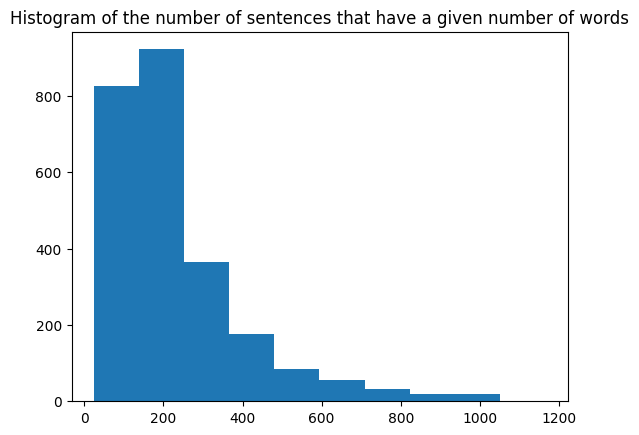

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_hist(X):
    len_ = [len(_) for _ in X]
    plt.hist(len_)
    plt.title('Histogram of the number of sentences that have a given number of words')
    plt.show()

plot_hist(X_train)


Muhtemelen cümlelerinizin %90 ila %95'inin 300 kelimeden az olduğunu göreceksiniz. Ve çok azı 1000 kelimeden fazladır.

Ancak, yukarıdaki dolguda `maxlen` kullanmadığınız için, girdi tensörünüzün boyutu, en fazla kelimeye sahip cümlenin uzunluğuna eşittir.

Şimdi, bunun dolguyu nasıl etkilediğine bakalım: 


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/NLP/tensor_size.png" alt='Dimensions of the tensor' width="700px" />

Birkaç çok uzun cümle nedeniyle, tensörünüzün bir boyutu yaklaşık 1000'e eşittir. Ancak, ~200 kelimelik cümlelerin çoğu, işe yaramayan dolgu değerlerine sahiptir.

Dolayısıyla, tensörünüz çoğunlukla işe yaramayan bilgilerden oluşur ve bu da eğitim sürecine zaman ekler.

Peki, verileri maksimum uzunluk (`maxlen`) olarak örneğin 200 (kelime) olacak şekilde doldurursanız ne olur?
- İlk olarak, bu yakınsamayı artıracak ve algoritmanın yakınsamayı beklerken ekrana bakmanıza gerek kalmayacaktır.
- Ancak esasen, gerçekten bu kadar çok bilgiyi kaybediyor musunuz? Bir cümlenin olumlu mu olumsuz mu olduğunu anlamak için genellikle 200 kelimeden (1000'e kadar) fazlasına ihtiyaç duyduğunuzu düşünüyor musunuz?

❓ **Soru** ❓ Tüm bu nedenlerden dolayı, `maxlen` anahtar kelimesini kullanarak dolguyu yeniden yapın ve modeli yeniden eğitin!  Performansı düşürmeden, şimdi ne kadar hızlı olduğunu görün ;)

In [12]:
# 1. Adım: Verileri maxlen=200 ile YENİDEN doldur (Padding)
# Sadece ilk 200 kelimeyi alacağız, eğer 200'den kısaysa sonuna sıfır ekleyeceğiz.
X_train_pad_fast = pad_sequences(X_train_token, dtype='int32', padding='post', maxlen=200)
X_test_pad_fast = pad_sequences(X_test_token, dtype='int32', padding='post', maxlen=200)

# 2. Adım: Modeli YENİDEN tanımla (Eskisinin üzerine yazmamak için yeni bir model objesi oluşturuyoruz)
model_fast = Sequential([
    Embedding(input_dim=vocab_size + 1, output_dim=50, mask_zero=True),
    SimpleRNN(units=64), 
    Dense(units=32, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

# 3. Adım: Yeni modeli derle
model_fast.compile(optimizer='adam', 
                   loss='binary_crossentropy', 
                   metrics=['accuracy'])

# 4. Adım: Yeni modeli YENİDEN eğit (Bu sefer çok daha hızlı olacak!)
print("Optimize edilmiş eğitim başlıyor...")

history_fast = model_fast.fit(
    X_train_pad_fast, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_pad_fast, y_test),
    callbacks=[es] # Önceki hücrede tanımladığımız EarlyStopping'i (es) aynen kullanıyoruz
)

Optimize edilmiş eğitim başlıyor...
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.5164 - loss: 0.6931 - val_accuracy: 0.5136 - val_loss: 0.7117
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.7776 - loss: 0.5400 - val_accuracy: 0.5284 - val_loss: 0.7774
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.9680 - loss: 0.1111 - val_accuracy: 0.5200 - val_loss: 1.3601
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.9824 - loss: 0.0649 - val_accuracy: 0.5564 - val_loss: 1.0979


🏁 Harika, artık `Tokenizer` ve `pad_sequences` kullanabilirsiniz.

💾 Not defterinizi git add/commit/push yapmayı unutmayın...

🚀 ... ve bir sonraki göreve geçin!